In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

In [7]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'SPY']
data = yf.download(tickers, start='2005-01-01', end='2026-01-01')['Close']

[*********************100%***********************]  4 of 4 completed


In [8]:
simple_returns = data.pct_change().dropna()
log_returns = np.log(data / data.shift(1)).dropna()

annual_return = log_returns.mean() * 252
annual_vol = log_returns.std() * np.sqrt(252)

In [20]:
vol_30

Ticker,AAPL,GOOGL,MSFT,SPY
Date,,,,
2005-01-04,NaN,NaN,NaN,NaN
2005-01-05,NaN,NaN,NaN,NaN
2005-01-06,NaN,NaN,NaN,NaN
2005-01-07,NaN,NaN,NaN,NaN
2005-01-10,NaN,NaN,NaN,NaN
...,...,...,...,...
2025-12-24,0.142276,0.326346,0.204941,0.122185
2025-12-26,0.141082,0.321952,0.204128,0.122195
2025-12-29,0.141015,0.307721,0.199782,0.111623


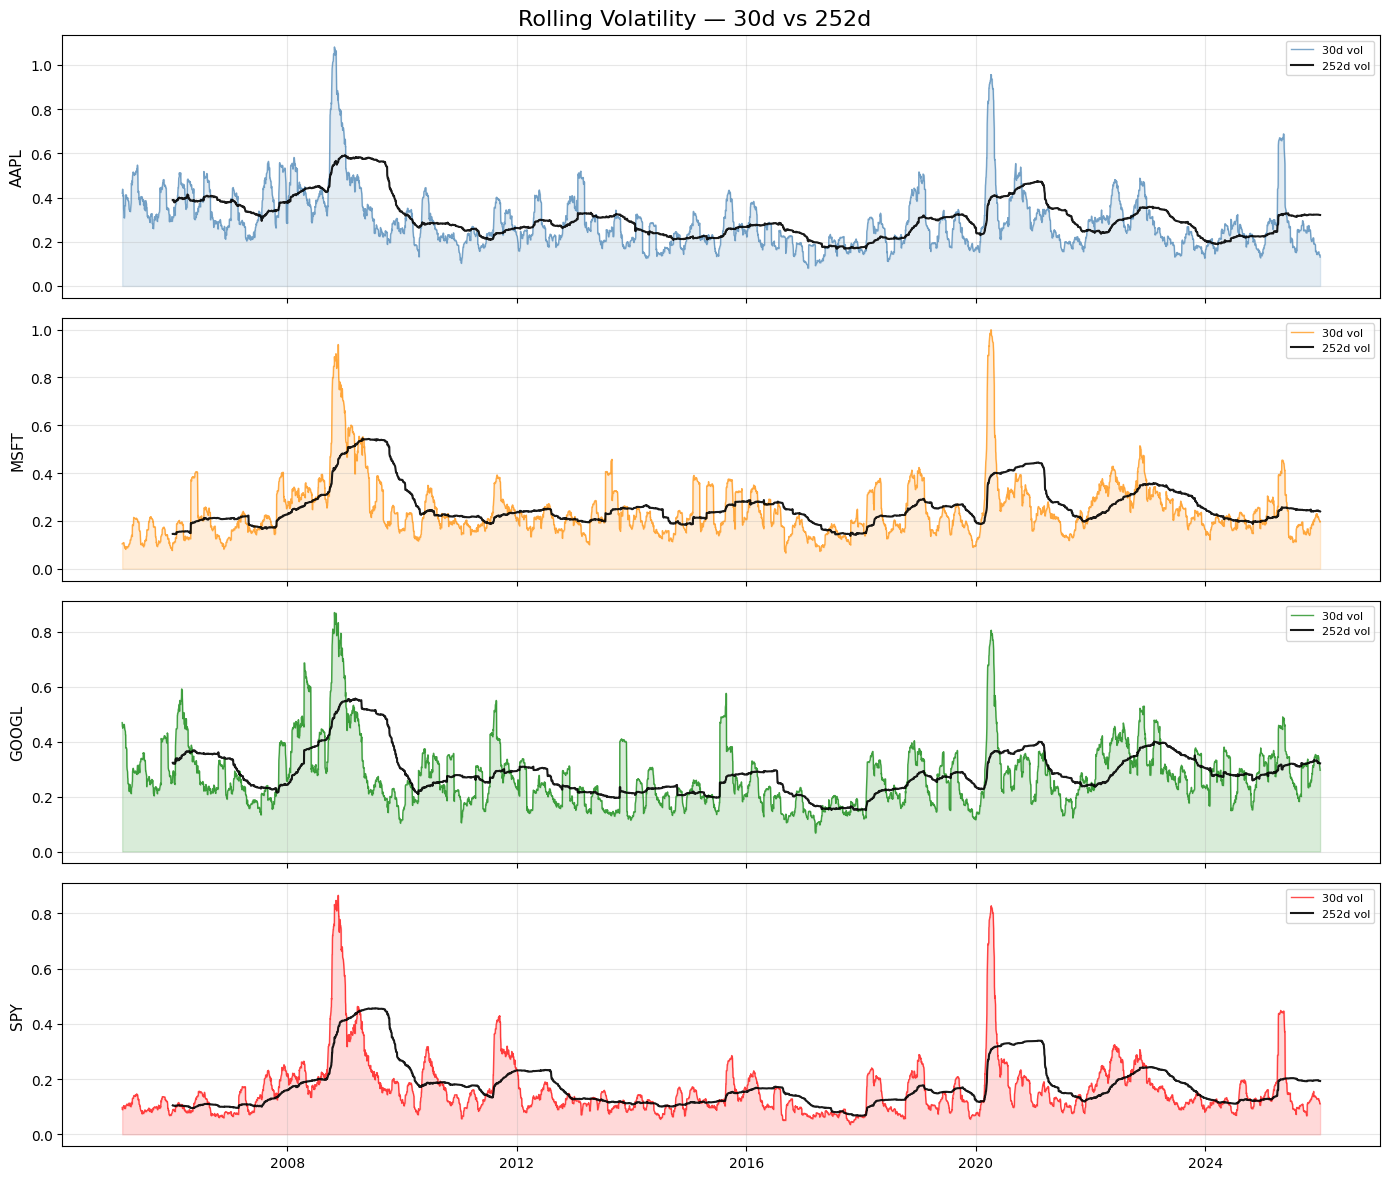

In [19]:
# volatility or standard deviation of stock returns. High volatitlity meaning less confidence
vol_30  = log_returns.rolling(30).std()  * np.sqrt(252)
vol_252 = log_returns.rolling(252).std() * np.sqrt(252)

fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 12), sharex=True)
fig.suptitle('Rolling Volatility — 30d vs 252d', fontsize=16)

for ax, ticker, color in zip(axes, tickers, colors):
    ax.plot(vol_30[ticker],  color=color,  alpha=0.7, linewidth=1,   label='30d vol')
    ax.plot(vol_252[ticker], color='black', alpha=0.9, linewidth=1.5, label='252d vol')
    ax.fill_between(vol_30.index, vol_30[ticker], alpha=0.15, color=color)
    ax.set_ylabel(ticker, fontsize=11)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

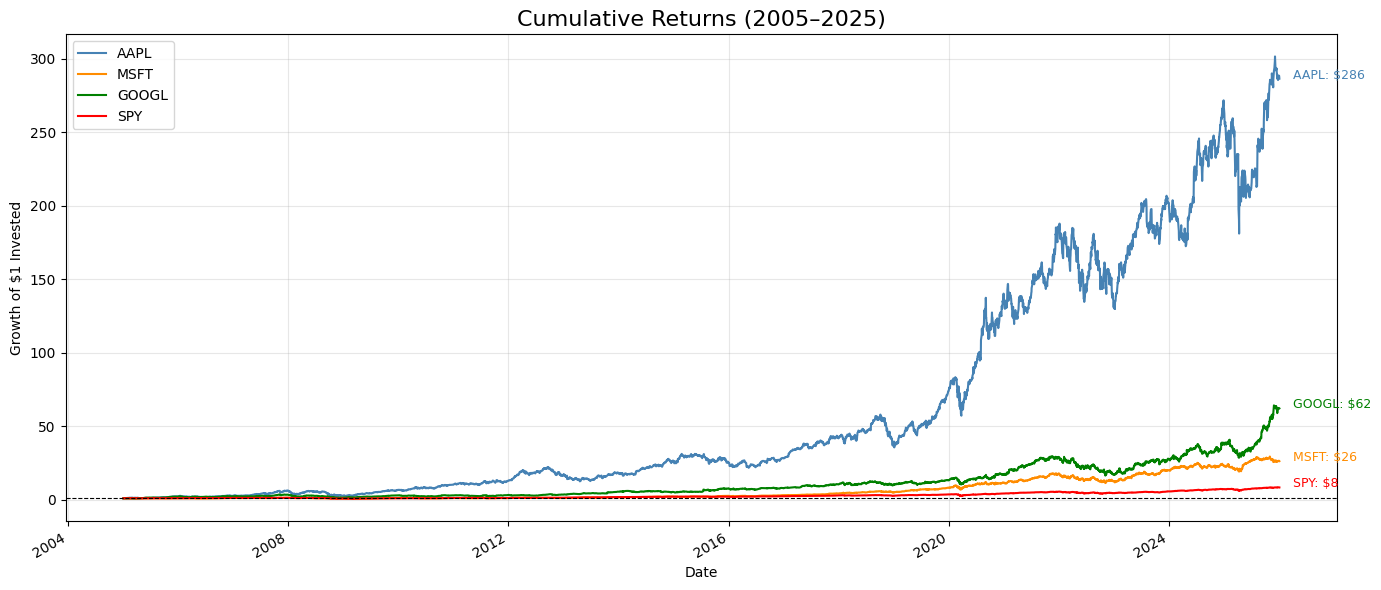

In [21]:
# cumulative returns over time
cumulative = np.exp(log_returns.cumsum())

fig, ax = plt.subplots(figsize=(14, 6))
for ticker, color in zip(tickers, colors):
    cumulative[ticker].plot(ax=ax, label=ticker, color=color, linewidth=1.5)

ax.set_title('Cumulative Returns (2005–2025)', fontsize=16)
ax.set_ylabel('Growth of $1 Invested')
ax.axhline(1, color='black', linestyle='--', linewidth=0.8)
ax.legend()
ax.grid(alpha=0.3)

# Annotate final values
for ticker, color in zip(tickers, colors):
    final = cumulative[ticker].iloc[-1]
    ax.annotate(f'{ticker}: ${final:.0f}',
                xy=(cumulative.index[-1], final),
                fontsize=9, color=color,
                xytext=(10, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

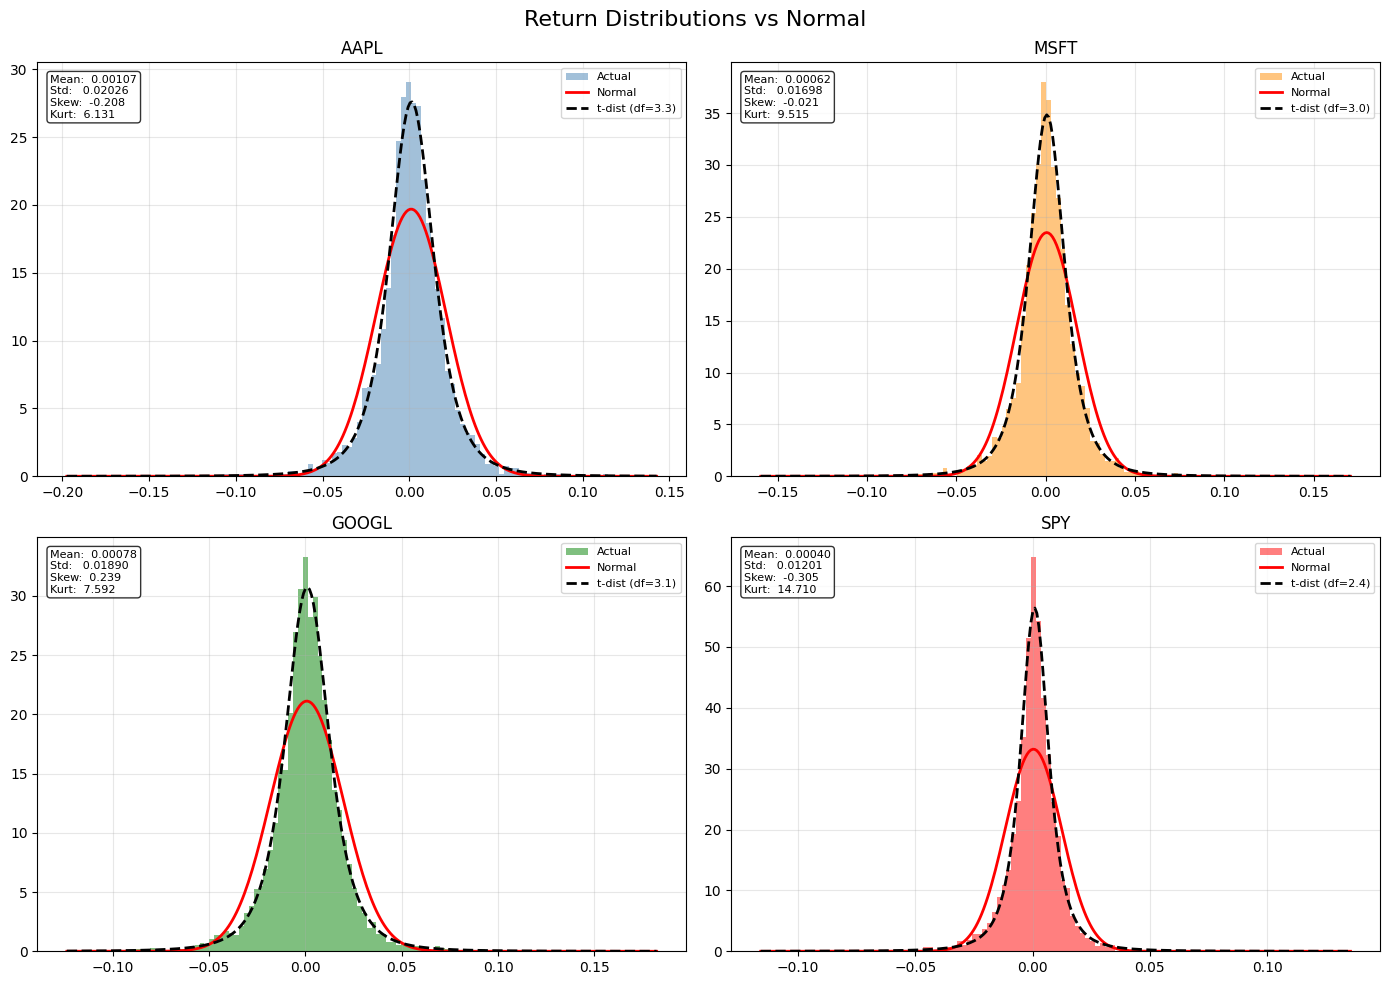

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Return Distributions vs Normal', fontsize=16)

for ax, ticker, color in zip(axes.flatten(), tickers, colors):
    ret = log_returns[ticker].dropna()
    
    # Histogram
    ax.hist(ret, bins=120, density=True, alpha=0.5,
            color=color, label='Actual')
    
    # Normal fit
    x = np.linspace(ret.min(), ret.max(), 300)
    ax.plot(x, stats.norm.pdf(x, ret.mean(), ret.std()),
            color='red', linewidth=2, label='Normal')
    
    # T-distribution fit
    df_t, loc_t, scale_t = stats.t.fit(ret)
    ax.plot(x, stats.t.pdf(x, df_t, loc_t, scale_t),
            color='black', linewidth=2, linestyle='--', label=f't-dist (df={df_t:.1f})')
    
    # Stats annotation
    textstr = (f'Mean:  {ret.mean():.5f}\n'
               f'Std:   {ret.std():.5f}\n'
               f'Skew:  {ret.skew():.3f}\n'
               f'Kurt:  {ret.kurtosis():.3f}')
    ax.text(0.02, 0.97, textstr, transform=ax.transAxes,
            verticalalignment='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_title(ticker)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

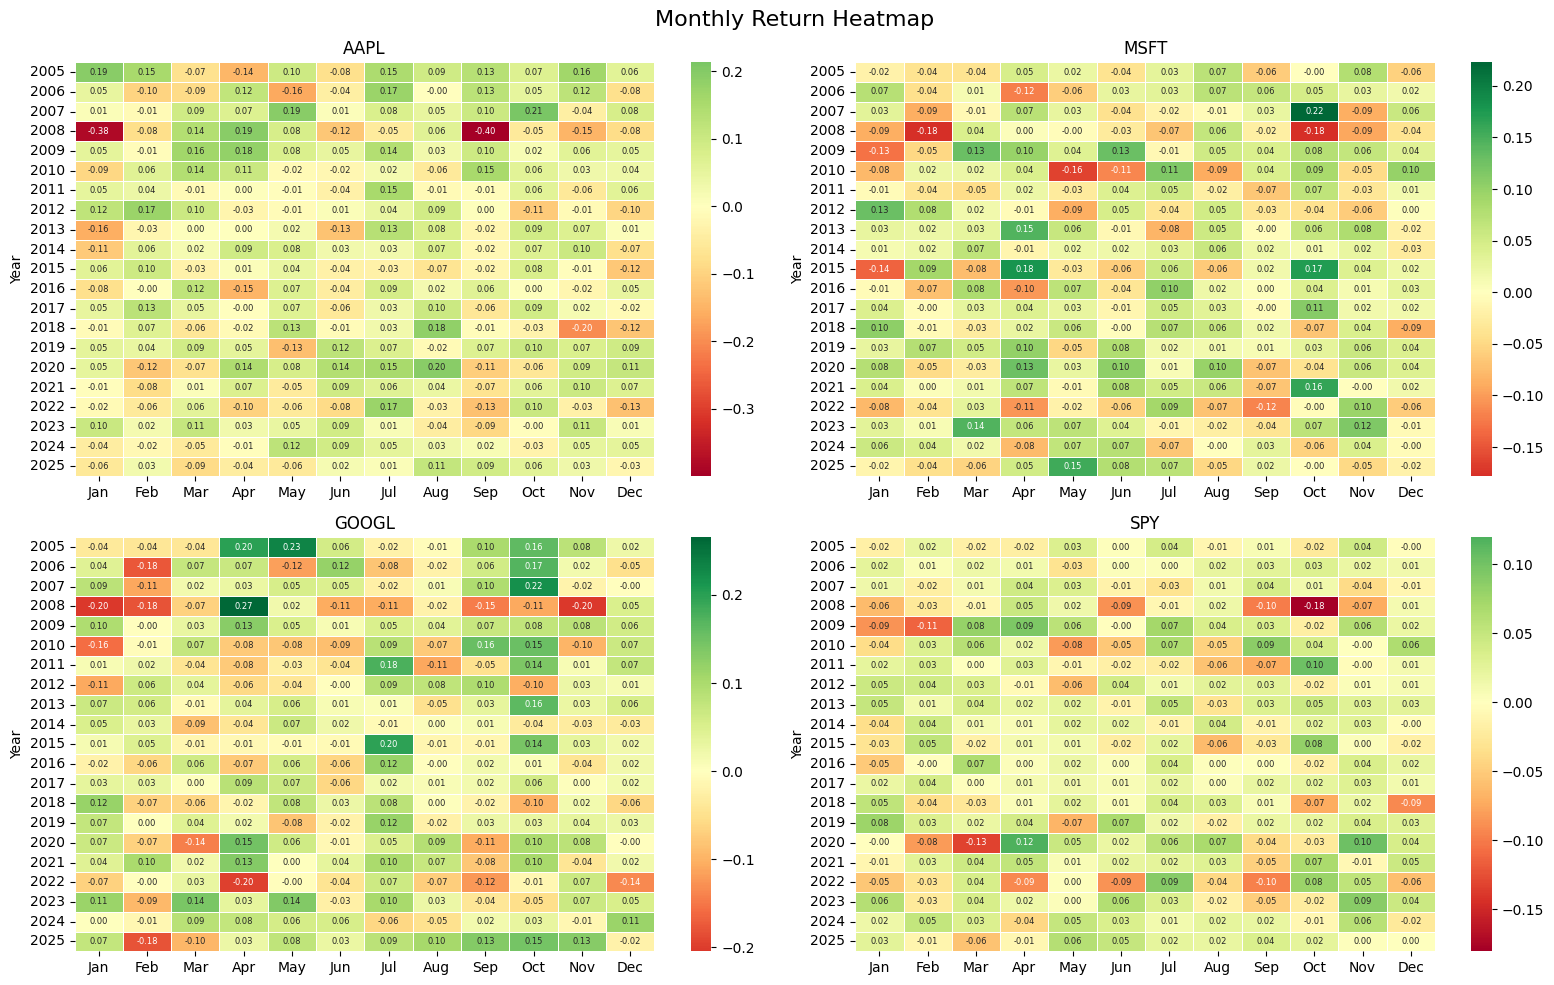

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Monthly Return Heatmap', fontsize=16)

for ax, ticker in zip(axes.flatten(), tickers):
    # Pivot to year × month grid
    monthly = log_returns[ticker].resample('ME').sum()
    monthly_df = monthly.to_frame()
    monthly_df['Year']  = monthly_df.index.year
    monthly_df['Month'] = monthly_df.index.month
    pivot = monthly_df.pivot(index='Year', columns='Month', values=ticker)
    pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec']
    
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, ax=ax, linewidths=0.5,
                annot_kws={'size': 6})
    ax.set_title(ticker)
    ax.set_ylabel('Year')

plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from itertools import product

#data reorganization for statistical analysis
tickers = ['AAPL', 'GOOGL', 'MSFT', 'SPY']

# Convert daily log returns into monthly log returns (sum = compounding)
monthly_log = log_returns.resample('MS').sum()   # MS = month start

# Define Crisis Windows 
crisis_2008  = pd.date_range('2008-01-01', '2009-12-01', freq='MS')
crisis_covid = pd.date_range('2020-01-01', '2020-12-01', freq='MS')
all_crisis   = crisis_2008.union(crisis_covid)

# Label Every Month 
monthly_log['entry_type'] = 'non_crisis'
monthly_log.loc[monthly_log.index.isin(crisis_2008),  'entry_type'] = 'crisis_2008'
monthly_log.loc[monthly_log.index.isin(crisis_covid), 'entry_type'] = 'crisis_covid'

# Categorical Variables
monthly_log['is_crisis']      = (monthly_log['entry_type'] != 'non_crisis').astype(int)
monthly_log['crisis_identity'] = pd.Categorical(
    monthly_log['entry_type'],
    categories=['non_crisis', 'crisis_2008', 'crisis_covid']
)

print("Monthly data shape:", monthly_log.shape)
print("\nEntry type counts:")
print(monthly_log['entry_type'].value_counts())
print("\nSample:")
print(monthly_log.head(3))

Monthly data shape: (252, 7)

Entry type counts:
entry_type
non_crisis      216
crisis_2008      24
crisis_covid     12
Name: count, dtype: int64

Sample:
Ticker          AAPL     GOOGL      MSFT       SPY  entry_type  is_crisis  \
Date                                                                        
2005-01-01  0.194778 -0.035602 -0.017352 -0.017949  non_crisis          0   
2005-02-01  0.154188 -0.039785 -0.040472  0.020689  non_crisis          0   
2005-03-01 -0.073765 -0.040603 -0.040143 -0.018462  non_crisis          0   

Ticker     crisis_identity  
Date                        
2005-01-01      non_crisis  
2005-02-01      non_crisis  
2005-03-01      non_crisis  


In [25]:
monthly_log

Ticker,AAPL,GOOGL,MSFT,SPY,entry_type,is_crisis,crisis_identity
Date,,,,,,,
2005-01-01,0.194778,-0.035602,-0.017352,-0.017949,non_crisis,0,non_crisis
2005-02-01,0.154188,-0.039785,-0.040472,0.020689,non_crisis,0,non_crisis
2005-03-01,-0.073765,-0.040603,-0.040143,-0.018462,non_crisis,0,non_crisis
2005-04-01,-0.144597,0.197841,0.045692,-0.018913,non_crisis,0,non_crisis
2005-05-01,0.097677,0.231364,0.022738,0.031717,non_crisis,0,non_crisis
...,...,...,...,...,...,...,...
2025-08-01,0.113006,0.103895,-0.049917,0.020312,non_crisis,0,non_crisis
2025-09-01,0.092471,0.133497,0.021979,0.035001,non_crisis,0,non_crisis
2025-10-01,0.059980,0.145558,-0.000270,0.023558,non_crisis,0,non_crisis
